# 03 — Latent Demand Potential Model
**DataStorm v7.0 | SkyNet Team**

## Problem Statement
Estimate the **latent maximum monthly volume potential** (in liters) for each outlet for January 2026.

**Key insight**: Historical volume is **censored** — it represents `min(true_demand, systemic_constraints)`.  
There is **no target variable (y)**. 'Potential' is a theoretical ceiling.

## Mathematical Framework — Two-Stage Uncapping

### Stage 1: Base Demand Estimation
Train XGBoost on `max_monthly_volume` as a **proxy lower bound** for true demand.  
This captures the complex feature interactions (outlet size, location, SKU breadth, etc.).

### Stage 2: Demand Uncapping
Apply constraint-based multipliers to lift censored predictions toward true potential:

```
potential_i = base_prediction_i × constraint_multiplier_i × jan26_seasonality_index_i
```

With protective bounds:
- **Floor**: `potential_i >= max_monthly_volume_i` (never predict below observed historical max)
- **Ceiling**: `potential_i <= peer_90th_potential_i × 2.0` (sanity bound against absurd predictions)

### Why This Is Defensible
1. `max_monthly_volume` is the empirical lower bound (outlet sold at least this much)
2. Constraint multipliers are derived from observable signals (credit hit rate, stockout gaps, delivery patterns)
3. Peer group 90th percentile provides external validation (what similar outlets actually sell)
4. Seasonality adjustment accounts for January-specific demand patterns

In [8]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import xgboost as xgb

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT))

GOLD_DIR = ROOT / 'data' / 'gold'
REPORTS  = ROOT / 'reports'
OUTPUTS  = ROOT / 'outputs'
REPORTS.mkdir(exist_ok=True)
OUTPUTS.mkdir(exist_ok=True)

sns.set_theme(style='darkgrid')
print('Imports successful')

Imports successful


## 1. Load Data

In [9]:
df = pd.read_csv(GOLD_DIR / 'outlet_features_with_constraints.csv')
print('Data loaded:', df.shape)

# ── Target: max_monthly_volume (proxy lower bound for true demand)
target = 'max_monthly_volume'

# ── Columns to EXCLUDE from XGBoost features ─────────────────────────────────
# These are either:
#   - Identifiers (Outlet_ID, dominant_distributor, peer_group)
#   - Target-correlated / leakage (mean_monthly_volume, median, total_volume, total_value)
#   - Applied AFTER XGBoost as multipliers (constraint_multiplier, jan26_seasonality_index)
#   - Derived peer columns used for post-processing (peer_90th, uncapping_factor, etc.)
#   - The target itself
exclude_cols = [
    'Outlet_ID',
    'dominant_distributor',
    'peer_group',
    'constraint_type',
    # Target and target-correlated
    'max_monthly_volume',
    'mean_monthly_volume',
    'median_monthly_volume',
    'total_volume',
    'total_value',
    # Post-prediction multipliers (applied in Stage 2)
    'constraint_multiplier',
    'jan26_seasonality_index',
    # Peer benchmark columns (used for sanity capping)
    'peer_90th_potential',
    'peer_75th_potential',
    'peer_group_size',
    'peer_percentile_rank',
    'uncapping_factor',
]

# ── Select features: everything numeric that's not excluded
all_cols = df.columns.tolist()
features = [c for c in all_cols if c not in exclude_cols and df[c].dtype in ['int64', 'float64', 'int32', 'float32', 'uint8']]

print(f'\nTarget: {target}')
print(f'Using {len(features)} features:')
for f in features:
    print(f'  {f}')

Data loaded: (19804, 76)

Target: max_monthly_volume
Using 60 features:
  std_monthly_volume
  cv_volume
  months_active
  zero_order_months
  order_frequency
  peak_to_avg_ratio
  credit_limit_hit_rate
  stockout_flag
  volume_trend
  jan_mean_volume
  jan_max_volume
  jan_min_volume
  jan_data_points
  jan_yoy_2023_2024
  jan_yoy_2024_2025
  sku_growth
  max_annual_sku_count
  Cooler_Count
  outlet_size_ord
  price_per_liter
  Latitude
  Longitude
  jan_total_holidays
  jan_poya_days
  jan_public_holidays
  poi_schools
  poi_universities
  poi_bus_stops
  poi_hospitals
  poi_clinics
  poi_hotels
  poi_guesthouses
  poi_markets
  poi_supermarkets
  poi_places_of_worship
  poi_pharmacies
  poi_fuel_stations
  poi_restaurants
  poi_banks
  poi_construction_sites
  poi_footfall_score
  poi_total_count
  is_urban
  Outlet_Size_Extra Large
  Outlet_Size_Large
  Outlet_Size_Medium
  Outlet_Size_Small
  Outlet_Type_Bakery
  Outlet_Type_Bakry
  Outlet_Type_Eatery
  Outlet_Type_Grocery
  Outle

## 2. Stage 1 — XGBoost Base Demand Model
Predict `max_monthly_volume` using behavioral features, outlet characteristics, January history, POI density, and geographic indicators.  
The model captures complex interactions that a simple rule-based approach would miss.

In [10]:
X = df[features].copy()
y = df[target].copy()

# Fill any remaining NaN in features
X = X.fillna(0)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    eval_metric='mae',
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)

# Evaluate
y_pred_val = model.predict(X_val)
mae = mean_absolute_error(y_val, y_pred_val)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
r2 = r2_score(y_val, y_pred_val)

print(f'Validation MAE:  {mae:.2f}')
print(f'Validation RMSE: {rmse:.2f}')
print(f'Validation R²:   {r2:.4f}')

Validation MAE:  4.92
Validation RMSE: 9.82
Validation R²:   0.9996


## 3. Model Diagnostics

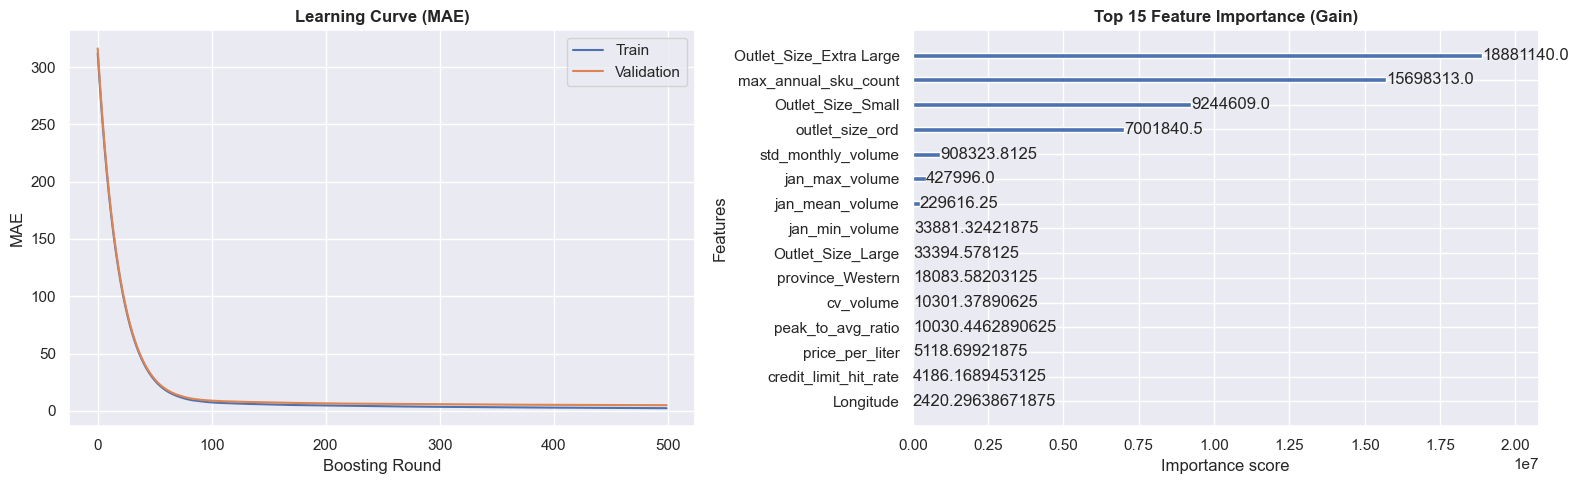

In [11]:
results = model.evals_result()
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Learning curve
axes[0].plot(results['validation_0']['mae'], label='Train', linewidth=1.5)
axes[0].plot(results['validation_1']['mae'], label='Validation', linewidth=1.5)
axes[0].set_title('Learning Curve (MAE)', fontweight='bold')
axes[0].set_xlabel('Boosting Round')
axes[0].set_ylabel('MAE')
axes[0].legend()

# Feature importance (gain)
xgb.plot_importance(model, max_num_features=15, importance_type='gain', ax=axes[1])
axes[1].set_title('Top 15 Feature Importance (Gain)', fontweight='bold')

plt.tight_layout()
plt.savefig(REPORTS / 'model_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Stage 2 — Demand Uncapping & Potential Estimation

The XGBoost prediction is a **base estimate** trained on censored data.  
We now apply the two-stage uncapping formula:

```
base = max(xgb_prediction, max_monthly_volume)  # protective floor
potential = base × constraint_multiplier × jan26_seasonality_index
potential = max(potential, max_monthly_volume)    # never below observed max
potential = min(potential, peer_90th × 2.0)       # sanity ceiling
```

In [12]:
# Predict base demand for ALL outlets
df['xgb_base_prediction'] = model.predict(X.fillna(0))

# Stage 2a: Protective floor — base is at least as high as observed max
df['base_demand'] = np.maximum(df['xgb_base_prediction'], df['max_monthly_volume'])

# Stage 2b: Apply constraint multiplier (uncapping censored demand)
df['uncapped_demand'] = df['base_demand'] * df['constraint_multiplier']

# Stage 2c: Apply seasonality adjustment (January 2026 specific)
# Seasonality is applied as a MULTIPLIER, not as an XGBoost feature
df['jan_2026_potential'] = df['uncapped_demand'] * df['jan26_seasonality_index']

# Stage 2d: Protective bounds
# Floor: never predict below historical max
df['jan_2026_potential'] = np.maximum(df['jan_2026_potential'], df['max_monthly_volume'])

# Ceiling: sanity cap at 2x peer 90th percentile (prevent absurd predictions)
peer_ceiling = df['peer_90th_potential'] * 2.0
df['jan_2026_potential'] = np.minimum(df['jan_2026_potential'], peer_ceiling)

print('=== Potential Estimation Summary ===')
print(f"\nObserved max_monthly_volume:")
print(df['max_monthly_volume'].describe().round(2))
print(f"\nEstimated jan_2026_potential:")
print(df['jan_2026_potential'].describe().round(2))
print(f"\nAverage uplift: {(df['jan_2026_potential'] / df['max_monthly_volume']).mean():.3f}x")

=== Potential Estimation Summary ===

Observed max_monthly_volume:
count    19804.00
mean       389.70
std        462.88
min         28.05
25%        111.36
50%        162.63
75%        344.19
max       2218.37
Name: max_monthly_volume, dtype: float64

Estimated jan_2026_potential:
count    19804.00
mean       433.14
std        515.21
min         32.21
25%        129.44
50%        198.56
75%        393.65
max       2800.02
Name: jan_2026_potential, dtype: float64

Average uplift: 1.141x


## 5. Uplift Analysis by Constraint Type

Uplift by Constraint Type:
                        count  avg_observed_max  avg_potential  avg_uplift  \
constraint_type                                                              
Delivery_Capped          7665            145.05         172.11        1.19   
Moderately_Constrained  12139            544.18         597.97        1.11   

                        constraint_mult  
constraint_type                          
Delivery_Capped                    1.15  
Moderately_Constrained             1.10  


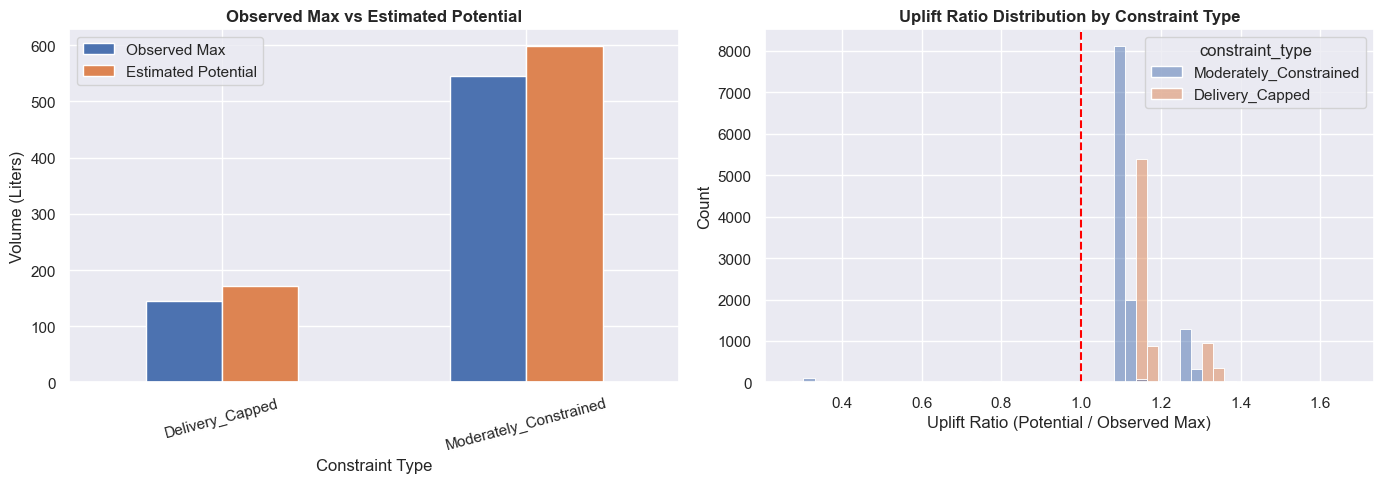

In [13]:
# Uplift by constraint type
df['uplift_ratio'] = df['jan_2026_potential'] / (df['max_monthly_volume'] + 1e-9)

uplift_summary = df.groupby('constraint_type').agg(
    count=('Outlet_ID', 'count'),
    avg_observed_max=('max_monthly_volume', 'mean'),
    avg_potential=('jan_2026_potential', 'mean'),
    avg_uplift=('uplift_ratio', 'mean'),
    constraint_mult=('constraint_multiplier', 'first'),
).round(2)

print('Uplift by Constraint Type:')
print(uplift_summary)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

uplift_summary[['avg_observed_max', 'avg_potential']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Observed Max vs Estimated Potential', fontweight='bold')
axes[0].set_xlabel('Constraint Type')
axes[0].set_ylabel('Volume (Liters)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(['Observed Max', 'Estimated Potential'])

sns.histplot(data=df, x='uplift_ratio', hue='constraint_type', bins=50,
             alpha=0.5, ax=axes[1])
axes[1].set_title('Uplift Ratio Distribution by Constraint Type', fontweight='bold')
axes[1].set_xlabel('Uplift Ratio (Potential / Observed Max)')
axes[1].axvline(1.0, color='red', linestyle='--', label='No uplift')

plt.tight_layout()
plt.savefig(REPORTS / 'uplift_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Save Model State & Potential Data

In [14]:
# Save complete results
output_path = GOLD_DIR / 'potential_demand_results.csv'
df.to_csv(output_path, index=False)
print(f'Saved potential demand results to {output_path}')
print(f'Total outlets: {len(df)}')
print(f'\nJanuary 2026 Forecast Statistics:')
print(df['jan_2026_potential'].describe().round(2))

Saved potential demand results to C:\Users\User\Documents\Projects\Datastorm\SkyNet-datastorm-v7\data\gold\potential_demand_results.csv
Total outlets: 19804

January 2026 Forecast Statistics:
count    19804.00
mean       433.14
std        515.21
min         32.21
25%        129.44
50%        198.56
75%        393.65
max       2800.02
Name: jan_2026_potential, dtype: float64
